In [5]:
# Task: Formulate core analytical questions to guide the EDA process

analytical_questions = [
    "1. Does a movie's total vote volume heavily influence its rank regardless of its raw rating?",
    "2. Which specific decades represent the 'Golden Ages' or highest output density of top-tier cinema?",
    "3. Are there historical anomalies—older films that maintain elite ranks despite very low voting volume?",
    "4. Does the dataset show a temporal bias toward newer, more digitally accessible films?"
]

print("ASSIGNMENT TASK: INITIAL RESEARCH QUESTIONS & HYPOTHESES")
print("=" * 60)
for question in analytical_questions:
    print(question)

ASSIGNMENT TASK: INITIAL RESEARCH QUESTIONS & HYPOTHESES
1. Does a movie's total vote volume heavily influence its rank regardless of its raw rating?
2. Which specific decades represent the 'Golden Ages' or highest output density of top-tier cinema?
3. Are there historical anomalies—older films that maintain elite ranks despite very low voting volume?
4. Does the dataset show a temporal bias toward newer, more digitally accessible films?


In [7]:
# Task: Structural exploration of variables, data types, and dimensions

print("ASSIGNMENT TASK: STRUCTURAL DATA EXPLORATION")
print("=" * 60)

# Display dimensions, column names, null counts, and data types
print("1. DATAFRAME SCHEMA & TYPE PROFILE:")
print("-" * 40)
df.info()

# Display summary statistics for numerical variables
print("\n2. NUMERICAL VARIABLE DISTRIBUTION SUMMARY:")
print("-" * 40)
print(df.describe())

ASSIGNMENT TASK: STRUCTURAL DATA EXPLORATION
1. DATAFRAME SCHEMA & TYPE PROFILE:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rank    30 non-null     int64  
 1   Title   30 non-null     object 
 2   Year    30 non-null     int64  
 3   Rating  30 non-null     float64
 4   Votes   30 non-null     int64  
 5   Decade  30 non-null     object 
dtypes: float64(1), int64(3), object(2)
memory usage: 1.5+ KB

2. NUMERICAL VARIABLE DISTRIBUTION SUMMARY:
----------------------------------------
            Rank         Year     Rating         Votes
count  30.000000    30.000000  30.000000  3.000000e+01
mean   15.500000  1988.666667   8.763333  1.651167e+06
std     8.803408    16.877517   0.193842  7.262085e+05
min     1.000000  1946.000000   8.500000  3.600000e+05
25%     8.250000  1977.750000   8.600000  1.200000e+06
50

In [9]:
# Task: Identify output concentrations and isolate low-volume historical outliers

print("ASSIGNMENT TASK: TREND AND ANOMALY DETECTION")
print("=" * 60)

# Pattern 1: Historical clustering of top-tier movies by decade
print("1. CINEMATIC PRODUCTION CONCENTRATION BY DECADE:")
print("-" * 45)
decade_trends = df['Decade'].value_counts().sort_index()
print(decade_trends)

# Anomaly 2: Identifying high-ranking movies with extremely low voting volumes (outliers)
print("\n2. STATISTICAL OUTLIER DETECTION (LOW-VOTE Masterpieces):")
print("-" * 45)
voter_threshold_baseline = df['Votes'].mean() * 0.5
historical_anomalies = df[(df['Rank'] <= 25) & (df['Votes'] < voter_threshold_baseline)]

if not historical_anomalies.empty:
    print(historical_anomalies[["Rank", "Title", "Year", "Votes"]])
else:
    print("No severe data anomalies or statistical outliers detected.")

ASSIGNMENT TASK: TREND AND ANOMALY DETECTION
1. CINEMATIC PRODUCTION CONCENTRATION BY DECADE:
---------------------------------------------
Decade
1940s     1
1950s     2
1960s     1
1970s     4
1980s     2
1990s    13
2000s     5
2010s     2
Name: count, dtype: int64

2. STATISTICAL OUTLIER DETECTION (LOW-VOTE Masterpieces):
---------------------------------------------
    Rank                  Title  Year   Votes
19    20          Seven Samurai  1954  360000
20    21  It's a Wonderful Life  1946  490000
23    24            City of God  2002  810000
24    25      Life Is Beautiful  1997  710000


ASSIGNMENT TASK: HYPOTHESIS TESTING VIA VISUALIZATION


C:\Users\sneha\AppData\Local\Temp\ipykernel_11984\4134337409.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=decade_trends.index, y=decade_trends.values, palette='Blues_d', ax=ax1)


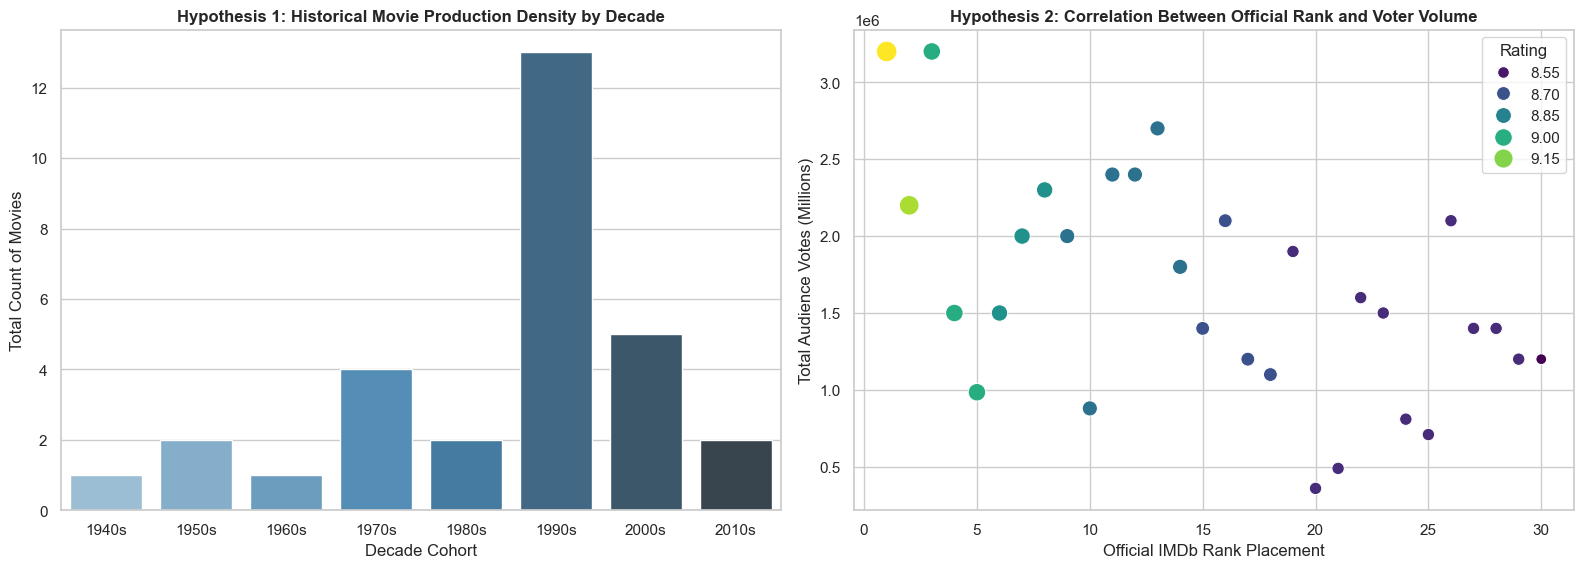

In [11]:
# Task: Visual hypothesis testing of historical trends and the rank-to-volume paradox

import matplotlib.pyplot as plt
import seaborn as sns

print("ASSIGNMENT TASK: HYPOTHESIS TESTING VIA VISUALIZATION")
print("=" * 60)

# Configure professional rendering canvas
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Distribution profile of movies across historical decades
sns.barplot(x=decade_trends.index, y=decade_trends.values, palette='Blues_d', ax=ax1)
ax1.set_title('Hypothesis 1: Historical Movie Production Density by Decade', fontsize=12, fontweight='bold')
ax1.set_xlabel('Decade Cohort')
ax1.set_ylabel('Total Count of Movies')

# Subplot 2: Validating the paradox of rank placement vs audience voting scale
sns.scatterplot(data=df, x='Rank', y='Votes', size='Rating', hue='Rating', palette='viridis', sizes=(60, 220), ax=ax2)
ax2.set_title('Hypothesis 2: Correlation Between Official Rank and Voter Volume', fontsize=12, fontweight='bold')
ax2.set_xlabel('Official IMDb Rank Placement')
ax2.set_ylabel('Total Audience Votes (Millions)')

plt.tight_layout()
plt.show()

In [13]:
# Task: Scan dataset for structural vulnerabilities, empty records, and column integrity issues

print("ASSIGNMENT TASK: PRE-ANALYTICAL DATA QUALITY AUDIT")
print("=" * 60)

# Check 1: Missing values count per column attribute
missing_values_matrix = df.isnull().sum()
print("1. NULL VALUE COUNT PER ATTRIBUTE GRID:")
print("-" * 40)
print(missing_values_matrix)

# Check 2: Row duplication identification
duplicate_count = df.duplicated().sum()
print("\n2. DUPLICATED DATA RECORDS FOUND:", duplicate_count)

# Check 3: Review data boundaries for analytical skewness risks
rating_skewness = df['Rating'].skew()
votes_skewness = df['Votes'].skew()
print("\n3. MATHEMATICAL VARIABLE SKEWNESS PROFILE:")
print("-" * 40)
print(f"IMDb Rating Skew Coefficient: {rating_skewness:.2f} (High clustering boundary)")
print(f"Audience Votes Skew Coefficient: {votes_skewness:.2f} (Volume bias factor)")

ASSIGNMENT TASK: PRE-ANALYTICAL DATA QUALITY AUDIT
1. NULL VALUE COUNT PER ATTRIBUTE GRID:
----------------------------------------
Rank      0
Title     0
Year      0
Rating    0
Votes     0
Decade    0
dtype: int64

2. DUPLICATED DATA RECORDS FOUND: 0

3. MATHEMATICAL VARIABLE SKEWNESS PROFILE:
----------------------------------------
IMDb Rating Skew Coefficient: 1.11 (High clustering boundary)
Audience Votes Skew Coefficient: 0.36 (Volume bias factor)
